# Deepfake Video Detection: ViT vs EfficientNet-B0 — Accuracy-Improved Final Kaggle Version

This independently written Kaggle notebook implements the UREC1 workflow:

- DFD Entire Original Dataset for development
- Deepfake Testing Videos as a held-out external set
- video-level splitting before frame extraction
- balanced sampling
- OpenCV face crop with centre-crop fallback
- detailed EDA and visualisations
- Vision Transformer and EfficientNet-B0 comparison
- validation-only model and threshold selection
- internal and external testing
- accuracy, precision, recall, specificity, F1, ROC-AUC, PR-AUC, EER and confusion matrices
- Grad-CAM
- export for a local Flask application

**Important:** high accuracy cannot be guaranteed. The design prioritises leakage control and honest testing.

### Resolved in this version
- Correct Kaggle dataset paths
- Correct DFD real/fake folder-based labelling
- Prevention of all videos being incorrectly labelled as fake
- Validation that both classes exist
- Optimised cached parallel frame extraction


**PyTorch 2.6 checkpoint loading is explicitly handled in this version.**

## 1. Install packages

In [1]:
!pip -q install timm grad-cam safetensors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.3 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Imports and configuration

In [2]:
import os, gc, json, math, random, shutil, warnings
from pathlib import Path
from collections import defaultdict
import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

warnings.filterwarnings("ignore")

class CFG:
    SEED=42
    IMAGE_SIZE=224
    FRAMES_PER_VIDEO=16
    BATCH_SIZE=16
    NUM_WORKERS=2
    EPOCHS=20
    PATIENCE=5
    LR=1e-4
    WEIGHT_DECAY=1e-4
    TRAIN_RATIO=0.70
    VAL_RATIO=0.15
    TEST_RATIO=0.15
    FACE_MARGIN=0.20
    MAX_VIDEOS_PER_CLASS=300  # use 100 for a fast trial
    MODELS=["efficientnet_b0","vit_base_patch16_224"]
    TRAIN_ROOT=Path("/kaggle/input/datasets/sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset")
    EXTERNAL_ROOT=Path("/kaggle/input/datasets/chandashekar8/deepfake-testing-videos")
    OUT=Path("/kaggle/working/deepfake_outputs")
    FRAMES=OUT/"frames"
    MODELS_DIR=OUT/"models"
    EXPORT=OUT/"flask_export"
    DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

for p in [CFG.OUT,CFG.FRAMES,CFG.MODELS_DIR,CFG.EXPORT]: p.mkdir(parents=True,exist_ok=True)

def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark=True
seed_all(CFG.SEED)

print("Device:",CFG.DEVICE)
print("PyTorch:",torch.__version__,"timm:",timm.__version__)

Device: cuda
PyTorch: 2.10.0+cu128 timm: 1.0.26


## 3. Build reproducible video manifest

In [3]:
VIDEO_EXT = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".m4v"}

def videos_under(root):
    root = Path(root)
    if not root.exists():
        return []
    return sorted(
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in VIDEO_EXT
    )

def dfd_label(path):
    text = str(path).lower().replace("\\", "/")

    # Use only class subfolder names. The top-level dataset name contains
    # "deep-fake", so searching the whole path for "fake" is incorrect.
    if "/dfd_manipulated_sequences/" in text:
        return 1
    if "/dfd_original sequences/" in text:
        return 0
    if "/dfd_original_sequences/" in text:
        return 0
    if "/dfd-original-sequences/" in text:
        return 0
    return None

if not CFG.TRAIN_ROOT.exists():
    raise FileNotFoundError(
        f"Training dataset path does not exist: {CFG.TRAIN_ROOT}"
    )

all_videos = videos_under(CFG.TRAIN_ROOT)

print("Dataset root:", CFG.TRAIN_ROOT)
print("Total videos found:", len(all_videos))

if not all_videos:
    raise FileNotFoundError(
        f"No supported videos were found under {CFG.TRAIN_ROOT}."
    )

rows = []
for path in all_videos:
    label = dfd_label(path)
    if label is None:
        continue
    rows.append({
        "video_path": str(path),
        "video_id": path.stem,
        "label": int(label),
        "class_name": "Real" if label == 0 else "Fake",
        "source": "DFD"
    })

full_manifest = (
    pd.DataFrame(rows)
    .drop_duplicates("video_path")
    .reset_index(drop=True)
)

if full_manifest.empty:
    print("Sample paths:")
    for p in all_videos[:20]:
        print(p)
    raise RuntimeError(
        "Videos were found, but DFD labels could not be inferred."
    )

counts = full_manifest["class_name"].value_counts()

print("\nTotal labelled videos:", len(full_manifest))
display(full_manifest.head())
display(counts.rename("videos").to_frame())

if not {"Real", "Fake"}.issubset(set(counts.index)):
    print("Sample paths:")
    for p in all_videos[:20]:
        print(p)
    raise RuntimeError(
        "Both Real and Fake classes must be present before continuing."
    )

assert full_manifest["video_path"].is_unique
assert set(full_manifest["label"].unique()) == {0, 1}

real_paths = full_manifest.loc[full_manifest["label"] == 0, "video_path"]
fake_paths = full_manifest.loc[full_manifest["label"] == 1, "video_path"]

print("\nExample real video:")
print(real_paths.iloc[0] if not real_paths.empty else "No real video found")

print("\nExample fake video:")
print(fake_paths.iloc[0] if not fake_paths.empty else "No fake video found")

print("\nManifest validation passed.")

Dataset root: /kaggle/input/datasets/sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset
Total videos found: 3431

Total labelled videos: 3431


,video_path,video_id,label,class_name,source
0,/kaggle/input/datasets/sanikatiwarekar/deep-fa...,01_02__exit_phone_room__YVGY8LOK,1,Fake,DFD
1,/kaggle/input/datasets/sanikatiwarekar/deep-fa...,01_02__hugging_happy__YVGY8LOK,1,Fake,DFD
2,/kaggle/input/datasets/sanikatiwarekar/deep-fa...,01_02__meeting_serious__YVGY8LOK,1,Fake,DFD
3,/kaggle/input/datasets/sanikatiwarekar/deep-fa...,01_02__outside_talking_still_laughing__YVGY8LOK,1,Fake,DFD
4,/kaggle/input/datasets/sanikatiwarekar/deep-fa...,01_02__secret_conversation__YVGY8LOK,1,Fake,DFD


,videos
class_name,
Fake,3068
Real,363



Example real video:
/kaggle/input/datasets/sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset/DFD_original sequences/01__exit_phone_room.mp4

Example fake video:
/kaggle/input/datasets/sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset/DFD_manipulated_sequences/DFD_manipulated_sequences/01_02__exit_phone_room__YVGY8LOK.mp4

Manifest validation passed.


## 4. Video-level EDA

fps                                          frames          \
            count  mean  std   min   25%   50%   75%   max  count    mean   
class_name                                                                  
Fake        104.0  24.0  0.0  24.0  24.0  24.0  24.0  24.0  104.0  697.70   
Real         16.0  24.0  0.0  24.0  24.0  24.0  24.0  24.0   16.0  898.38   

            ...   width         height                                       \
            ...     75%     max  count    mean  std     min     25%     50%   
class_name  ...                                                               
Fake        ...  1920.0  1920.0  104.0  1080.0  0.0  1080.0  1080.0  1080.0   
Real        ...  1920.0  1920.0   16.0  1080.0  0.0  1080.0  1080.0  1080.0   

                            
               75%     max  
class_name                  
Fake        1080.0  1080.0  
Real        1080.0  1080.0  

[2 rows x 40 columns]

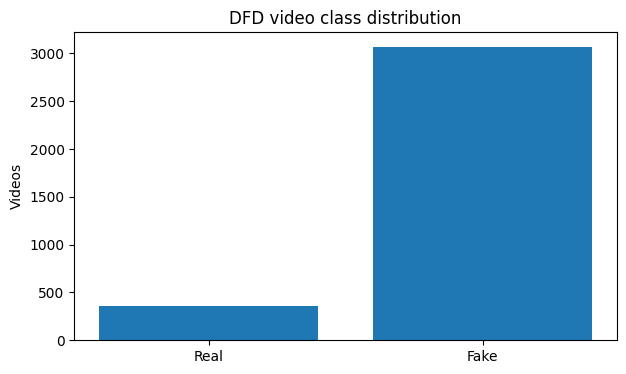

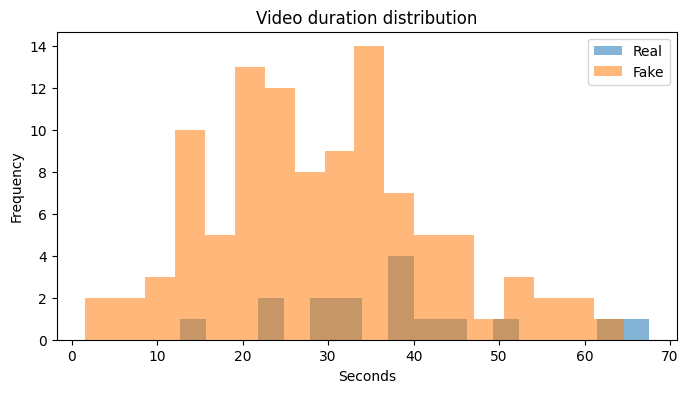

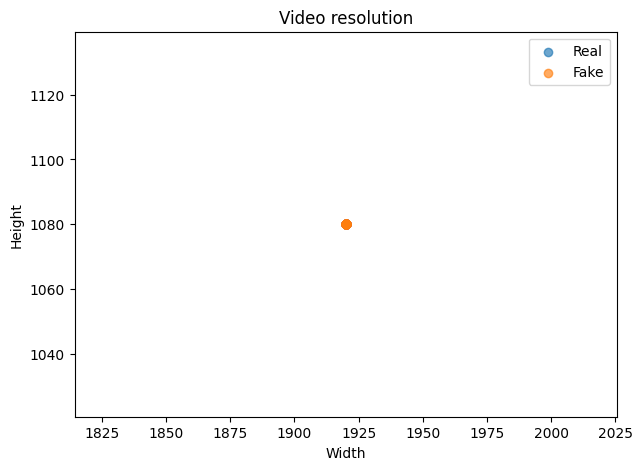

In [4]:
def video_meta(path):
    cap=cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return pd.Series({"fps":np.nan,"frames":np.nan,"duration":np.nan,"width":np.nan,"height":np.nan})
    fps=cap.get(cv2.CAP_PROP_FPS); n=cap.get(cv2.CAP_PROP_FRAME_COUNT)
    out={"fps":fps,"frames":n,"duration":n/fps if fps>0 else np.nan,
         "width":cap.get(cv2.CAP_PROP_FRAME_WIDTH),"height":cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}
    cap.release(); return pd.Series(out)

audit=full_manifest.sample(min(120,len(full_manifest)),random_state=CFG.SEED).copy()
audit=pd.concat([audit.reset_index(drop=True),audit["video_path"].apply(video_meta).reset_index(drop=True)],axis=1)
display(audit.groupby("class_name")[["fps","frames","duration","width","height"]].describe().round(2))

plt.figure(figsize=(7,4))
vc=full_manifest["class_name"].value_counts().reindex(["Real","Fake"])
plt.bar(vc.index,vc.values); plt.title("DFD video class distribution"); plt.ylabel("Videos"); plt.show()

plt.figure(figsize=(8,4))
for c in ["Real","Fake"]:
    plt.hist(audit.loc[audit.class_name==c,"duration"].dropna(),bins=18,alpha=.55,label=c)
plt.title("Video duration distribution"); plt.xlabel("Seconds"); plt.ylabel("Frequency"); plt.legend(); plt.show()

plt.figure(figsize=(7,5))
for c in ["Real","Fake"]:
    d=audit[audit.class_name==c]
    plt.scatter(d.width,d.height,alpha=.65,label=c)
plt.title("Video resolution"); plt.xlabel("Width"); plt.ylabel("Height"); plt.legend(); plt.show()

## 5. Balance and split at video level

class_name,Fake,Real
split,,
test,45,45
train,210,210
val,45,45


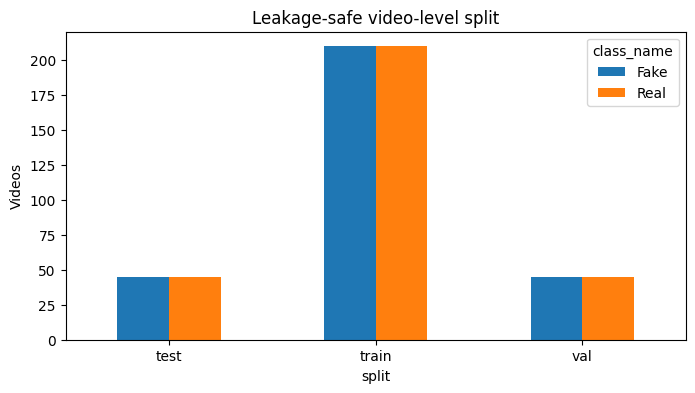

In [5]:
def balanced_sample(df,max_per_class=None):
    n=df.label.value_counts().min()
    if max_per_class is not None: n=min(n,max_per_class)
    return pd.concat([g.sample(n,random_state=CFG.SEED) for _,g in df.groupby("label")]).sample(frac=1,random_state=CFG.SEED)

balanced=balanced_sample(full_manifest,CFG.MAX_VIDEOS_PER_CLASS)
train_df,temp=train_test_split(balanced,test_size=.30,stratify=balanced.label,random_state=CFG.SEED)
val_df,test_df=train_test_split(temp,test_size=.50,stratify=temp.label,random_state=CFG.SEED)
train_df=train_df.assign(split="train"); val_df=val_df.assign(split="val"); test_df=test_df.assign(split="test")
video_manifest=pd.concat([train_df,val_df,test_df],ignore_index=True)

assert set(train_df.video_path).isdisjoint(val_df.video_path)
assert set(train_df.video_path).isdisjoint(test_df.video_path)
assert set(val_df.video_path).isdisjoint(test_df.video_path)

video_manifest.to_csv(CFG.OUT/"video_manifest.csv",index=False)
display(pd.crosstab(video_manifest.split,video_manifest.class_name))
pd.crosstab(video_manifest.split,video_manifest.class_name).plot(kind="bar",figsize=(8,4))
plt.title("Leakage-safe video-level split"); plt.ylabel("Videos"); plt.xticks(rotation=0); plt.show()

## 6. Uniform frames and face crops

### Runtime guidance for frame extraction

The optimized cell below uses parallel video processing, reduced-resolution face detection, cache reuse, and a progress bar.

For a quick pipeline test, set the following in the configuration cell and rerun the balancing/splitting cells:

```python
CFG.MAX_VIDEOS_PER_CLASS = 100
CFG.FRAMES_PER_VIDEO = 8
```

For the final experiment, a practical configuration is:

```python
CFG.MAX_VIDEOS_PER_CLASS = 300
CFG.FRAMES_PER_VIDEO = 10
```

Do not delete previously extracted frame folders. Complete cached folders are reused automatically, while incomplete folders are rebuilt.

In [6]:
# ============================================================
# Optimized frame extraction and face cropping
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# Prevent excessive internal OpenCV threading.
cv2.setNumThreads(0)

# Recommended Kaggle setting.
# Reduce to 2 if memory use becomes high.
FRAME_WORKERS = 4

# Faster Haar settings.
HAAR_SCALE_FACTOR = 1.20
HAAR_MIN_NEIGHBORS = 4
HAAR_MIN_FACE_SIZE = (48, 48)

haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"


def get_face_detector():
    # Create one detector per worker instead of sharing one object.
    return cv2.CascadeClassifier(haar_path)


def centre_crop(frame):
    h, w = frame.shape[:2]
    side = min(h, w)
    y1 = max((h - side) // 2, 0)
    x1 = max((w - side) // 2, 0)
    return frame[y1:y1 + side, x1:x1 + side]


def crop_face_fast(frame, detector):
    # Detect the largest face on a reduced-size image.
    if frame is None or frame.size == 0:
        return None, False

    original_h, original_w = frame.shape[:2]
    detection_width = 480

    if original_w > detection_width:
        scale = detection_width / original_w
        detection_frame = cv2.resize(
            frame,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_AREA
        )
    else:
        scale = 1.0
        detection_frame = frame

    gray = cv2.cvtColor(detection_frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)

    faces = detector.detectMultiScale(
        gray,
        scaleFactor=HAAR_SCALE_FACTOR,
        minNeighbors=HAAR_MIN_NEIGHBORS,
        minSize=HAAR_MIN_FACE_SIZE
    )

    if len(faces) == 0:
        return centre_crop(frame), False

    x, y, w, h = max(faces, key=lambda box: box[2] * box[3])

    if scale != 1.0:
        x = int(x / scale)
        y = int(y / scale)
        w = int(w / scale)
        h = int(h / scale)

    margin_x = int(w * CFG.FACE_MARGIN)
    margin_y = int(h * CFG.FACE_MARGIN)

    x1 = max(0, x - margin_x)
    y1 = max(0, y - margin_y)
    x2 = min(original_w, x + w + margin_x)
    y2 = min(original_h, y + h + margin_y)

    crop = frame[y1:y2, x1:x2]

    if crop is None or crop.size == 0:
        return centre_crop(frame), False

    return crop, True


def valid_cached_frames(output_dir, expected_count):
    # Reuse previously completed frame folders.
    files = sorted(output_dir.glob("frame_*.jpg"))

    if len(files) < expected_count:
        return []

    files = files[:expected_count]

    for path in files:
        image = cv2.imread(str(path))
        if image is None or image.size == 0:
            return []

    return files


def make_cached_records(row, files):
    records = []

    for path in files:
        records.append({
            "frame_path": str(path),
            "video_id": row.video_id,
            "video_path": row.video_path,
            "label": int(row.label),
            "class_name": row.class_name,
            "split": row.split,
            "frame_index": np.nan,
            "face_detected": np.nan,
            "cached": True
        })

    return records


def extract_video_fast(row):
    detector = get_face_detector()

    output_dir = (
        CFG.FRAMES
        / str(row.split)
        / str(row.class_name).lower()
        / str(row.video_id)
    )
    output_dir.mkdir(parents=True, exist_ok=True)

    cached = valid_cached_frames(
        output_dir,
        CFG.FRAMES_PER_VIDEO
    )

    if cached:
        return {
            "records": make_cached_records(row, cached),
            "video_id": row.video_id,
            "status": "cached",
            "read_failures": 0
        }

    # Clear only incomplete cached outputs.
    for old_file in output_dir.glob("frame_*.jpg"):
        old_file.unlink(missing_ok=True)

    cap = cv2.VideoCapture(str(row.video_path))

    if not cap.isOpened():
        return {
            "records": [],
            "video_id": row.video_id,
            "status": "cannot_open",
            "read_failures": CFG.FRAMES_PER_VIDEO
        }

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return {
            "records": [],
            "video_id": row.video_id,
            "status": "invalid_frame_count",
            "read_failures": CFG.FRAMES_PER_VIDEO
        }

    # Avoid beginning/end transitions where blank frames can occur.
    start_index = int(total_frames * 0.02)
    end_index = max(start_index, int(total_frames * 0.98) - 1)

    frame_indices = np.linspace(
        start_index,
        end_index,
        CFG.FRAMES_PER_VIDEO
    ).astype(int)

    records = []
    read_failures = 0

    for frame_number, frame_index in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
        success, frame = cap.read()

        if not success or frame is None:
            read_failures += 1
            continue

        face_crop, detected = crop_face_fast(frame, detector)

        if face_crop is None or face_crop.size == 0:
            read_failures += 1
            continue

        face_crop = cv2.resize(
            face_crop,
            (CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
            interpolation=cv2.INTER_AREA
        )

        output_path = output_dir / f"frame_{frame_number:03d}.jpg"

        saved = cv2.imwrite(
            str(output_path),
            face_crop,
            [cv2.IMWRITE_JPEG_QUALITY, 90]
        )

        if not saved:
            read_failures += 1
            continue

        records.append({
            "frame_path": str(output_path),
            "video_id": row.video_id,
            "video_path": row.video_path,
            "label": int(row.label),
            "class_name": row.class_name,
            "split": row.split,
            "frame_index": int(frame_index),
            "face_detected": bool(detected),
            "cached": False
        })

    cap.release()

    return {
        "records": records,
        "video_id": row.video_id,
        "status": "completed" if records else "no_frames",
        "read_failures": read_failures
    }


# Run extraction in parallel.
rows = list(video_manifest.itertuples(index=False))

all_records = []
processing_log = []

with ThreadPoolExecutor(max_workers=FRAME_WORKERS) as executor:
    futures = {
        executor.submit(extract_video_fast, row): row.video_id
        for row in rows
    }

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Extracting video frames"
    ):
        video_id = futures[future]

        try:
            result = future.result()
            all_records.extend(result["records"])

            processing_log.append({
                "video_id": result["video_id"],
                "status": result["status"],
                "frames_saved": len(result["records"]),
                "read_failures": result["read_failures"]
            })

        except Exception as error:
            processing_log.append({
                "video_id": video_id,
                "status": "exception",
                "frames_saved": 0,
                "read_failures": CFG.FRAMES_PER_VIDEO,
                "error": str(error)
            })


frames = pd.DataFrame(all_records)
processing_log_df = pd.DataFrame(processing_log)

if frames.empty:
    raise RuntimeError(
        "No frames were extracted. Check dataset paths and video readability."
    )

frames.to_csv(
    CFG.OUT / "frame_manifest.csv",
    index=False
)

processing_log_df.to_csv(
    CFG.OUT / "frame_extraction_log.csv",
    index=False
)

print("\nFrame extraction completed")
print("-" * 60)
print("Frames:", len(frames))
print("Videos represented:", frames["video_id"].nunique())
print("Expected videos:", len(video_manifest))

if frames["face_detected"].notna().any():
    detection_rate = frames["face_detected"].dropna().mean()
    print(f"Face detection rate: {detection_rate:.2%}")

print("\nProcessing status:")
display(processing_log_df["status"].value_counts().to_frame("videos"))

print("\nFrames by split and class:")
display(pd.crosstab(frames["split"], frames["class_name"]))

Extracting video frames:   0%|          | 0/600 [00:00<?, ?it/s]


Frame extraction completed
------------------------------------------------------------
Frames: 9600
Videos represented: 600
Expected videos: 600
Face detection rate: 71.17%

Processing status:


,videos
status,
completed,600



Frames by split and class:


class_name,Fake,Real
split,,
test,720,720
train,3360,3360
val,720,720


## 7. Detailed frame EDA and visualisations

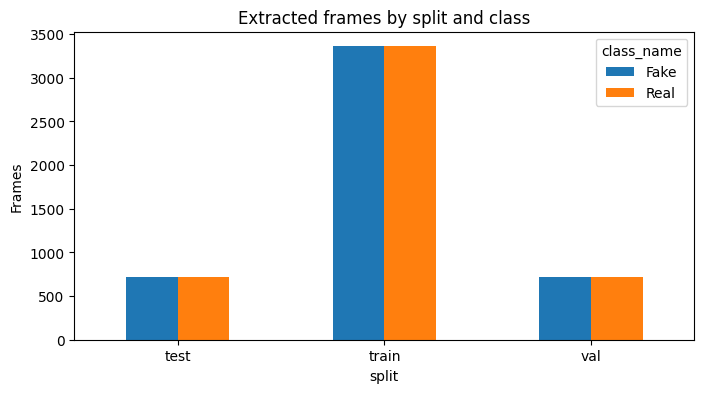

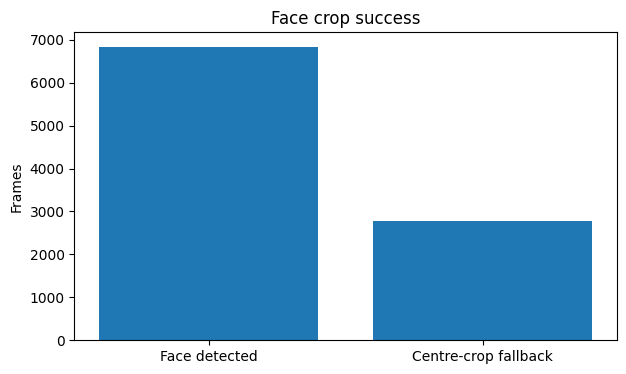

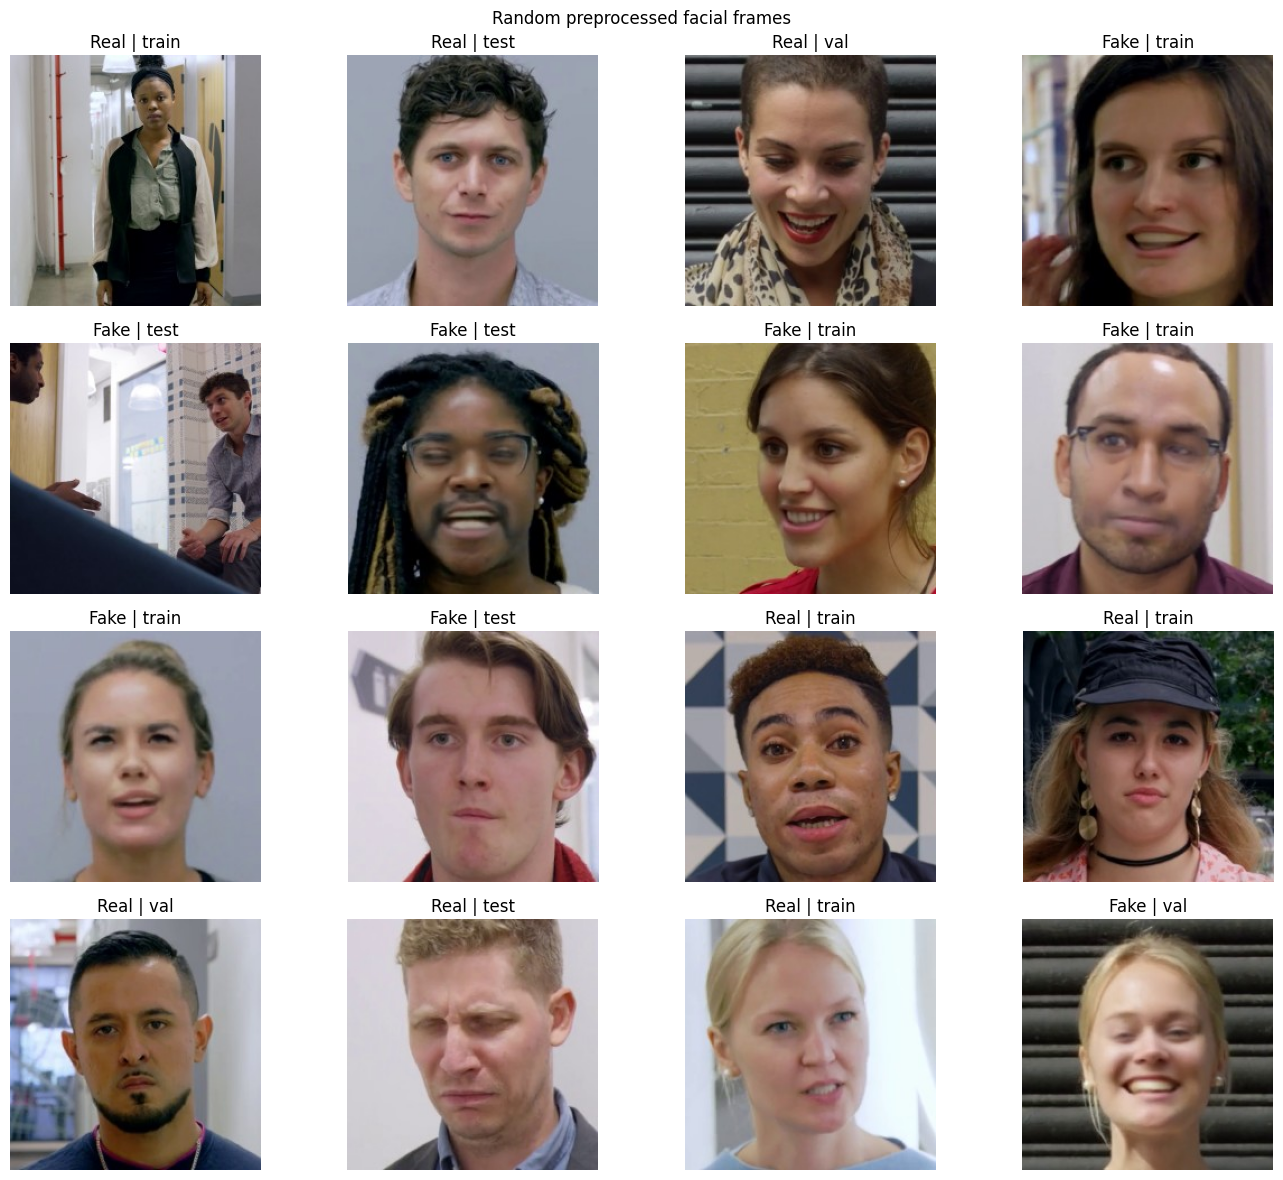

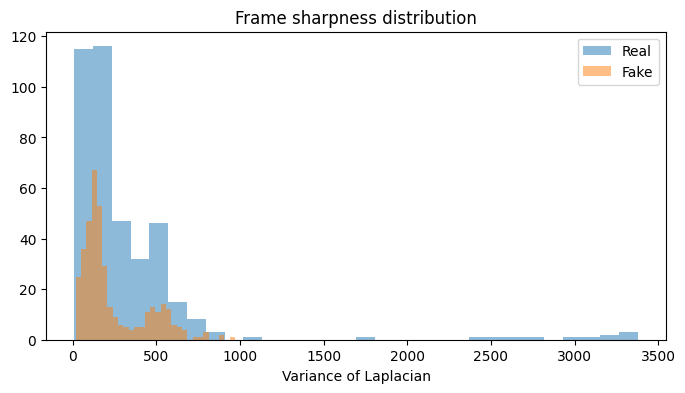

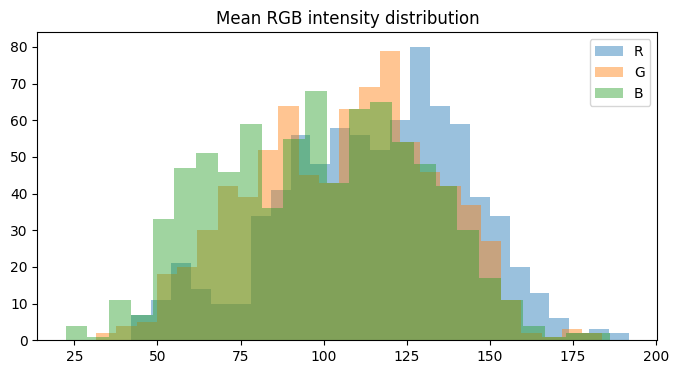

In [7]:
pd.crosstab(frames.split,frames.class_name).plot(kind="bar",figsize=(8,4))
plt.title("Extracted frames by split and class"); plt.ylabel("Frames"); plt.xticks(rotation=0); plt.show()

if frames.face_detected.notna().any():
    q=frames.face_detected.map({True:"Face detected",False:"Centre-crop fallback"}).value_counts()
    plt.figure(figsize=(7,4)); plt.bar(q.index,q.values); plt.title("Face crop success"); plt.ylabel("Frames"); plt.show()

sample=frames.sample(min(16,len(frames)),random_state=CFG.SEED)
plt.figure(figsize=(14,12))
for i,r in enumerate(sample.itertuples(index=False),1):
    img=cv2.cvtColor(cv2.imread(r.frame_path),cv2.COLOR_BGR2RGB)
    plt.subplot(4,4,i); plt.imshow(img); plt.title(f"{r.class_name} | {r.split}"); plt.axis("off")
plt.suptitle("Random preprocessed facial frames"); plt.tight_layout(); plt.show()

def sharpness(path):
    g=cv2.imread(path,cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(g,cv2.CV_64F).var()

eda=frames.sample(min(800,len(frames)),random_state=CFG.SEED).copy()
eda["sharpness"]=eda.frame_path.apply(sharpness)
plt.figure(figsize=(8,4))
for c in ["Real","Fake"]:
    v=eda.loc[eda.class_name==c,"sharpness"]; v=v[v<v.quantile(.98)]
    plt.hist(v,bins=30,alpha=.5,label=c)
plt.title("Frame sharpness distribution"); plt.xlabel("Variance of Laplacian"); plt.legend(); plt.show()

channel={"R":[],"G":[],"B":[]}
for p in eda.frame_path:
    im=cv2.cvtColor(cv2.imread(p),cv2.COLOR_BGR2RGB).reshape(-1,3).mean(0)
    for k,v in zip(channel,im): channel[k].append(v)
plt.figure(figsize=(8,4))
for k,v in channel.items(): plt.hist(v,bins=25,alpha=.45,label=k)
plt.title("Mean RGB intensity distribution"); plt.legend(); plt.show()

## 8. PyTorch datasets

In [ ]:
MEAN=[.485,.456,.406]; STD=[.229,.224,.225]
train_tf=transforms.Compose([
    transforms.Resize((CFG.IMAGE_SIZE,CFG.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(.18,.18,.12,.03)],p=.65),
    transforms.RandomRotation(8),
    transforms.RandomAffine(0,translate=(.04,.04),scale=(.95,1.05)),
    transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
eval_tf=transforms.Compose([
    transforms.Resize((CFG.IMAGE_SIZE,CFG.IMAGE_SIZE)),
    transforms.ToTensor(),transforms.Normalize(MEAN,STD)])

class FrameDS(Dataset):
    def __init__(self,df,tf): self.df=df.reset_index(drop=True); self.tf=tf
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        return {"image":self.tf(Image.open(r.frame_path).convert("RGB")),
                "label":torch.tensor(int(r.label)),
                "video_id":r.video_id,"frame_path":r.frame_path}

tr=frames[frames.split=="train"]; va=frames[frames.split=="val"]; te=frames[frames.split=="test"]
weights=tr.label.map({k:1/v for k,v in tr.label.value_counts().items()}).values
sampler=WeightedRandomSampler(weights,len(weights),replacement=True)

train_loader=DataLoader(FrameDS(tr,train_tf),CFG.BATCH_SIZE,sampler=sampler,num_workers=CFG.NUM_WORKERS,pin_memory=True)
val_loader=DataLoader(FrameDS(va,eval_tf),CFG.BATCH_SIZE,shuffle=False,num_workers=CFG.NUM_WORKERS,pin_memory=True)
test_loader=DataLoader(FrameDS(te,eval_tf),CFG.BATCH_SIZE,shuffle=False,num_workers=CFG.NUM_WORKERS,pin_memory=True)
print(len(tr),len(va),len(te))

6720 1440 1440


## Accuracy and comparison note

The reference implementation reports high validation accuracy, but it randomly splits extracted frames. Frames from the same source video can therefore appear in both training and validation, which can inflate performance. This notebook retains the UREC1 requirement of splitting at video level before frame extraction.

To improve performance without leakage, this version uses:

- 300 videos per class by default;
- 16 frames per video;
- classifier warm-up followed by full fine-tuning;
- focal cross-entropy;
- learning-rate reduction;
- early stopping;
- horizontal-flip test-time augmentation;
- robust video-level probability aggregation;
- validation-only threshold selection.

The resulting score may still be lower than a frame-random-split score, but it is a more defensible measure of performance on unseen videos.

## 9. Train EfficientNet-B0 and Vision Transformer

In [ ]:
def make_model(name, pretrained=True):
    model = timm.create_model(
        name,
        pretrained=pretrained,
        num_classes=2,
        drop_rate=0.30,
        drop_path_rate=0.10
    )
    return model.to(CFG.DEVICE)

class FocalCrossEntropy(nn.Module):
    def __init__(self, gamma=1.5, label_smoothing=0.03):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(
            reduction="none",
            label_smoothing=label_smoothing
        )

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        pt = torch.softmax(logits, dim=1).gather(
            1, targets.unsqueeze(1)
        ).squeeze(1).clamp_min(1e-6)
        return (((1.0 - pt) ** self.gamma) * ce).mean()

def set_backbone_trainable(model, trainable):
    # Freeze/unfreeze all parameters first.
    for parameter in model.parameters():
        parameter.requires_grad = trainable

    # Keep the classifier trainable during warm-up.
    classifier = model.get_classifier()
    if isinstance(classifier, nn.Module):
        for parameter in classifier.parameters():
            parameter.requires_grad = True

def epoch_pass(model, loader, criterion, optimizer=None, scaler=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    labels_all, probs_all = [], []

    for batch in loader:
        images = batch["image"].to(CFG.DEVICE, non_blocking=True)
        labels = batch["label"].to(CFG.DEVICE, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(images)
            loss = criterion(logits, labels)

        if is_training:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        probabilities = torch.softmax(logits, dim=1)[:, 1]
        total_loss += float(loss.item()) * images.size(0)
        labels_all.extend(labels.detach().cpu().numpy().tolist())
        probs_all.extend(probabilities.detach().cpu().numpy().tolist())

    labels_all = np.asarray(labels_all, dtype=int)
    probs_all = np.asarray(probs_all, dtype=float)

    auc = (
        float(roc_auc_score(labels_all, probs_all))
        if len(np.unique(labels_all)) == 2
        else float("nan")
    )

    return {
        "loss": total_loss / max(len(loader.dataset), 1),
        "roc_auc": auc,
        "labels": labels_all,
        "probs": probs_all
    }

def train_one(name):
    model = make_model(name, pretrained=True)
    criterion = FocalCrossEntropy(gamma=1.5, label_smoothing=0.03)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    checkpoint_path = CFG.MODELS_DIR / f"{name}_best.pt"
    history = []
    best_val_auc = -1.0
    patience_counter = 0

    # Stage 1: classifier warm-up.
    set_backbone_trainable(model, False)
    warmup_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=3e-4,
        weight_decay=CFG.WEIGHT_DECAY
    )

    for warmup_epoch in range(1, 3):
        train_result = epoch_pass(
            model, train_loader, criterion,
            warmup_optimizer, scaler
        )
        val_result = epoch_pass(model, val_loader, criterion)

        history.append({
            "epoch": warmup_epoch,
            "stage": "warmup",
            "train_loss": train_result["loss"],
            "val_loss": val_result["loss"],
            "train_auc": train_result["roc_auc"],
            "val_auc": val_result["roc_auc"]
        })

        print(
            f"{name} warm-up {warmup_epoch}/2 | "
            f"train loss={train_result['loss']:.4f} | "
            f"val loss={val_result['loss']:.4f} | "
            f"val AUC={val_result['roc_auc']:.4f}"
        )

    # Stage 2: fine-tune the full model at a smaller learning rate.
    set_backbone_trainable(model, True)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG.LR,
        weight_decay=CFG.WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )

    for epoch in range(1, CFG.EPOCHS + 1):
        train_result = epoch_pass(
            model, train_loader, criterion,
            optimizer, scaler
        )
        val_result = epoch_pass(model, val_loader, criterion)
        scheduler.step(val_result["roc_auc"])

        history.append({
            "epoch": epoch + 2,
            "stage": "fine_tune",
            "train_loss": train_result["loss"],
            "val_loss": val_result["loss"],
            "train_auc": train_result["roc_auc"],
            "val_auc": val_result["roc_auc"],
            "learning_rate": optimizer.param_groups[0]["lr"]
        })

        print(
            f"{name} epoch {epoch:02d}/{CFG.EPOCHS} | "
            f"train loss={train_result['loss']:.4f} | "
            f"val loss={val_result['loss']:.4f} | "
            f"train AUC={train_result['roc_auc']:.4f} | "
            f"val AUC={val_result['roc_auc']:.4f}"
        )

        current_auc = float(val_result["roc_auc"])

        if current_auc > best_val_auc + 1e-4:
            best_val_auc = current_auc
            patience_counter = 0

            # Store only safe Python primitives and tensors.
            torch.save({
                "model_name": str(name),
                "state_dict": model.state_dict(),
                "best_val_auc": float(best_val_auc),
                "image_size": int(CFG.IMAGE_SIZE)
            }, checkpoint_path)
        else:
            patience_counter += 1

            if patience_counter >= CFG.PATIENCE:
                print("Early stopping.")
                break

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        CFG.OUT / f"{name}_training_history.csv",
        index=False
    )

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return checkpoint_path, history_df

checkpoints = {}
histories = {}

for model_name in CFG.MODELS:
    print("\n" + "=" * 88)
    print("Training:", model_name)
    print("=" * 88)

    checkpoints[model_name], histories[model_name] = train_one(model_name)


Training: efficientnet_b0


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

efficientnet_b0 warm-up 1/2 | train loss=2.4399 | val loss=2.2501 | val AUC=0.4423
efficientnet_b0 warm-up 2/2 | train loss=2.2472 | val loss=2.0096 | val AUC=0.4549
efficientnet_b0 epoch 01/20 | train loss=1.3058 | val loss=1.3221 | train AUC=0.7554 | val AUC=0.7423
efficientnet_b0 epoch 02/20 | train loss=0.5696 | val loss=0.9003 | train AUC=0.8739 | val AUC=0.8012
efficientnet_b0 epoch 03/20 | train loss=0.4245 | val loss=0.8554 | train AUC=0.8985 | val AUC=0.8058
efficientnet_b0 epoch 04/20 | train loss=0.3436 | val loss=0.9998 | train AUC=0.9207 | val AUC=0.8003
efficientnet_b0 epoch 05/20 | train loss=0.2900 | val loss=0.8851 | train AUC=0.9334 | val AUC=0.8073
efficientnet_b0 epoch 06/20 | train loss=0.2454 | val loss=0.7898 | train AUC=0.9425 | val AUC=0.8353
efficientnet_b0 epoch 07/20 | train loss=0.2201 | val loss=0.7709 | train AUC=0.9513 | val AUC=0.8442
efficientnet_b0 epoch 08/20 | train loss=0.2040 | val loss=0.7835 | train AUC=0.9528 | val AUC=0.8362
efficientnet_b0 ep

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

vit_base_patch16_224 warm-up 1/2 | train loss=0.3620 | val loss=0.2939 | val AUC=0.5673
vit_base_patch16_224 warm-up 2/2 | train loss=0.2636 | val loss=0.2780 | val AUC=0.5742
vit_base_patch16_224 epoch 01/20 | train loss=0.2716 | val loss=0.2711 | train AUC=0.5091 | val AUC=0.5633
vit_base_patch16_224 epoch 02/20 | train loss=0.2546 | val loss=0.2615 | train AUC=0.5154 | val AUC=0.5708
vit_base_patch16_224 epoch 03/20 | train loss=0.2483 | val loss=0.2477 | train AUC=0.5449 | val AUC=0.5517
vit_base_patch16_224 epoch 04/20 | train loss=0.2475 | val loss=0.2500 | train AUC=0.5529 | val AUC=0.5065
vit_base_patch16_224 epoch 05/20 | train loss=0.2449 | val loss=0.2490 | train AUC=0.5715 | val AUC=0.5742
vit_base_patch16_224 epoch 06/20 | train loss=0.2396 | val loss=0.2744 | train AUC=0.6164 | val AUC=0.5690
vit_base_patch16_224 epoch 07/20 | train loss=0.2409 | val loss=0.2593 | train AUC=0.6053 | val AUC=0.4711
vit_base_patch16_224 epoch 08/20 | train loss=0.2361 | val loss=0.2460 | tr

## 10. Training curves

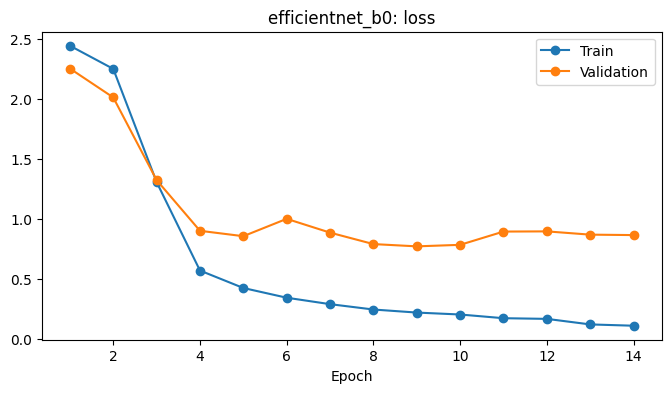

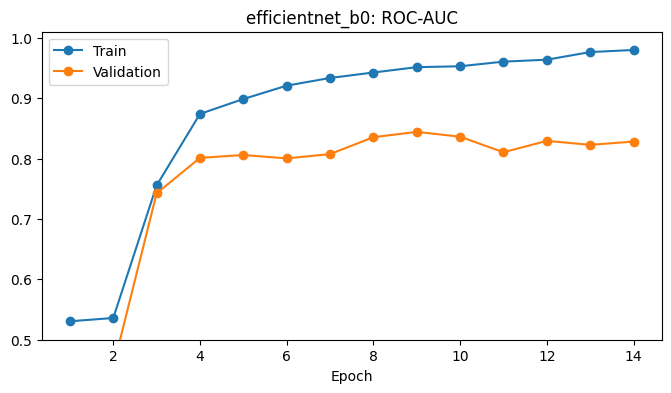

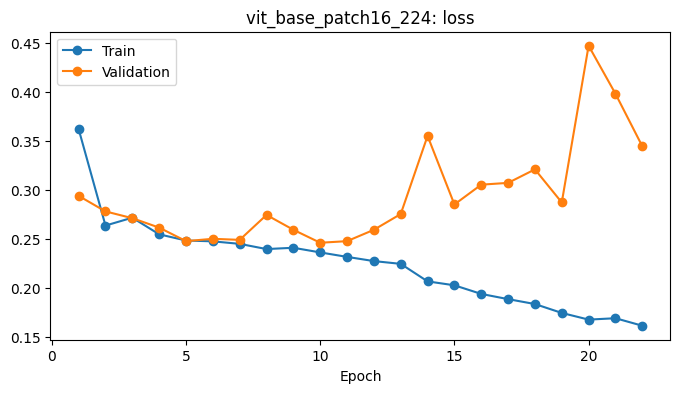

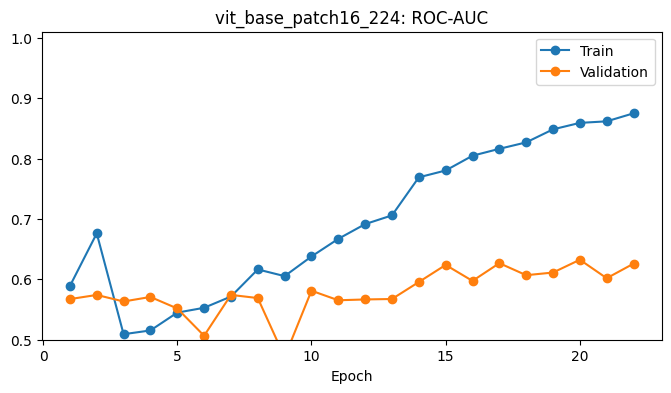

In [ ]:
for name,h in histories.items():
    plt.figure(figsize=(8,4)); plt.plot(h.epoch,h.train_loss,marker="o",label="Train")
    plt.plot(h.epoch,h.val_loss,marker="o",label="Validation")
    plt.title(f"{name}: loss"); plt.xlabel("Epoch"); plt.legend(); plt.show()
    plt.figure(figsize=(8,4)); plt.plot(h.epoch,h.train_auc,marker="o",label="Train")
    plt.plot(h.epoch,h.val_auc,marker="o",label="Validation")
    plt.title(f"{name}: ROC-AUC"); plt.xlabel("Epoch"); plt.ylim(.5,1.01); plt.legend(); plt.show()

## 11. Validation threshold and all UREC1 metrics

In [ ]:
def load_ckpt(path):
    # These checkpoints are created by this notebook, so weights_only=False
    # is safe here and resolves the PyTorch 2.6 loading change.
    checkpoint = torch.load(
        path,
        map_location=CFG.DEVICE,
        weights_only=False
    )

    model = make_model(
        checkpoint["model_name"],
        pretrained=False
    )
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    return model, checkpoint

@torch.no_grad()
def predict(model, loader, use_tta=True):
    rows = []

    for batch in loader:
        images = batch["image"].to(
            CFG.DEVICE,
            non_blocking=True
        )

        logits = model(images)
        probability = torch.softmax(logits, dim=1)[:, 1]

        # Horizontal-flip test-time augmentation.
        if use_tta:
            flipped = torch.flip(images, dims=[3])
            flipped_logits = model(flipped)
            flipped_probability = torch.softmax(
                flipped_logits,
                dim=1
            )[:, 1]

            probability = (
                probability + flipped_probability
            ) / 2.0

        probability = probability.cpu().numpy()

        rows.extend(zip(
            batch["video_id"],
            batch["frame_path"],
            batch["label"].numpy(),
            probability
        ))

    return pd.DataFrame(
        rows,
        columns=[
            "video_id",
            "frame_path",
            "label",
            "prob_fake"
        ]
    )

def video_level(frame_predictions):
    # Robust aggregation: remove the most extreme frame probability
    # from each side when enough frames are present.
    def robust_probability(values):
        values = np.sort(np.asarray(values, dtype=float))

        if len(values) >= 8:
            trim = max(1, int(round(len(values) * 0.10)))
            values = values[trim:-trim]

        return float(np.mean(values))

    return (
        frame_predictions
        .groupby("video_id", as_index=False)
        .agg(
            label=("label", "first"),
            prob_fake=("prob_fake", robust_probability),
            frames=("prob_fake", "size")
        )
    )

def threshold_youden(labels, probabilities):
    fpr, tpr, thresholds = roc_curve(
        labels,
        probabilities
    )
    index = int(np.argmax(tpr - fpr))
    threshold = float(thresholds[index])

    # Keep the chosen threshold within a meaningful probability range.
    return float(np.clip(threshold, 0.05, 0.95))

def equal_error_rate(labels, probabilities):
    fpr, tpr, _ = roc_curve(labels, probabilities)
    fnr = 1.0 - tpr
    index = int(np.argmin(np.abs(fnr - fpr)))
    return float((fpr[index] + fnr[index]) / 2.0)

def calculate_metrics(labels, probabilities, threshold):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision_score(
            labels, predictions, zero_division=0
        )),
        "recall": float(recall_score(
            labels, predictions, zero_division=0
        )),
        "specificity": float(tn / max(tn + fp, 1)),
        "f1": float(f1_score(
            labels, predictions, zero_division=0
        )),
        "roc_auc": float(roc_auc_score(
            labels, probabilities
        )),
        "pr_auc": float(average_precision_score(
            labels, probabilities
        )),
        "eer": equal_error_rate(
            labels, probabilities
        ),
        "threshold": float(threshold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

results = []
preds = {}

for model_name, checkpoint_path in checkpoints.items():
    model, checkpoint = load_ckpt(checkpoint_path)

    validation_frames = predict(
        model,
        val_loader,
        use_tta=True
    )
    validation_videos = video_level(validation_frames)

    selected_threshold = threshold_youden(
        validation_videos["label"],
        validation_videos["prob_fake"]
    )

    print(
        f"{model_name}: selected validation threshold "
        f"= {selected_threshold:.4f}"
    )

    for split_name, loader in [
        ("validation", val_loader),
        ("internal_test", test_loader)
    ]:
        frame_predictions = predict(
            model,
            loader,
            use_tta=True
        )
        video_predictions = video_level(
            frame_predictions
        )

        results.append({
            "model": model_name,
            "split": split_name,
            "level": "frame",
            **calculate_metrics(
                frame_predictions["label"],
                frame_predictions["prob_fake"],
                selected_threshold
            )
        })

        results.append({
            "model": model_name,
            "split": split_name,
            "level": "video",
            **calculate_metrics(
                video_predictions["label"],
                video_predictions["prob_fake"],
                selected_threshold
            )
        })

        preds[
            (model_name, split_name, "frame")
        ] = frame_predictions

        preds[
            (model_name, split_name, "video")
        ] = video_predictions

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

metrics_df = pd.DataFrame(results)
metrics_df.to_csv(
    CFG.OUT / "all_metrics.csv",
    index=False
)

display(metrics_df.round(4))

efficientnet_b0: selected validation threshold = 0.6590
vit_base_patch16_224: selected validation threshold = 0.6530


,model,split,level,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,eer,threshold,tn,fp,fn,tp
0,efficientnet_b0,validation,frame,0.7396,0.7386,0.7417,0.7375,0.7401,0.8453,0.8715,0.2590,0.659,531,189,186,534
1,efficientnet_b0,validation,video,0.8222,0.8222,0.8222,0.8222,0.8222,0.8894,0.8986,0.1778,0.659,37,8,8,37
2,efficientnet_b0,internal_test,frame,0.7403,0.7338,0.7542,0.7264,0.7438,0.8397,0.8285,0.2576,0.659,523,197,177,543
3,efficientnet_b0,internal_test,video,0.8444,0.8780,0.8000,0.8889,0.8372,0.8825,0.8520,0.2000,0.659,40,5,9,36
4,vit_base_patch16_224,validation,frame,0.6097,0.6508,0.4736,0.7458,0.5482,0.6406,0.6395,0.3958,0.653,537,183,379,341
5,vit_base_patch16_224,validation,video,0.6778,0.7667,0.5111,0.8444,0.6133,0.6716,0.7022,0.3889,0.653,38,7,22,23
6,vit_base_patch16_224,internal_test,frame,0.5583,0.5820,0.4139,0.7028,0.4838,0.5954,0.5396,0.4236,0.653,506,214,422,298
7,vit_base_patch16_224,internal_test,video,0.6111,0.6667,0.4444,0.7778,0.5333,0.6321,0.5696,0.4000,0.653,35,10,25,20


## 12. Model comparison, confusion matrices, ROC and PR curves

,model,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,eer
3,efficientnet_b0,0.8444,0.8780,0.8000,0.8889,0.8372,0.8825,0.8520,0.2
7,vit_base_patch16_224,0.6111,0.6667,0.4444,0.7778,0.5333,0.6321,0.5696,0.4


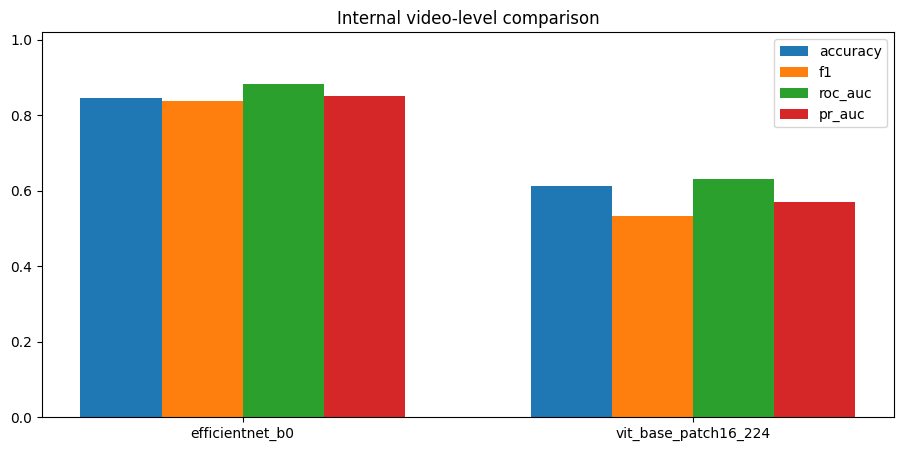

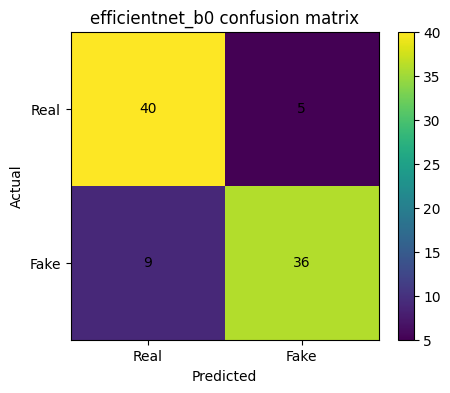

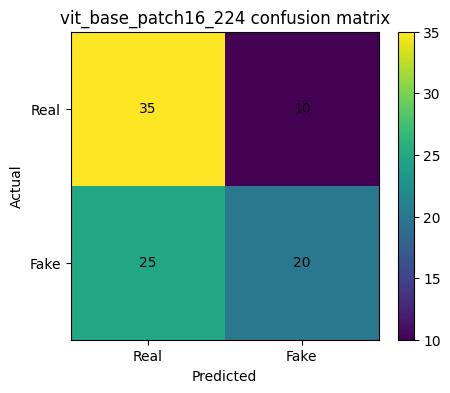

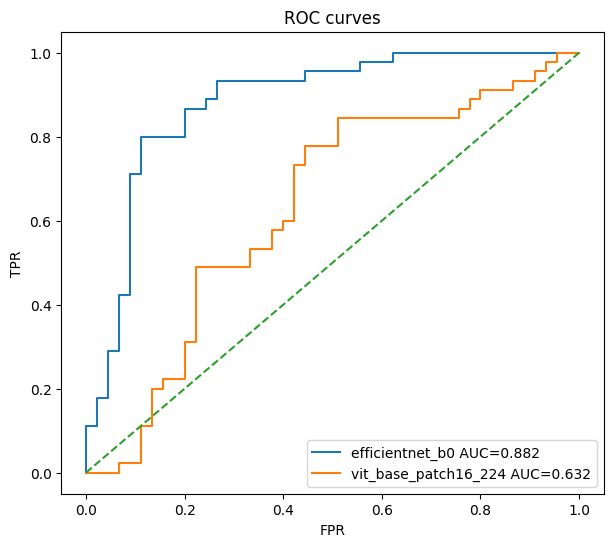

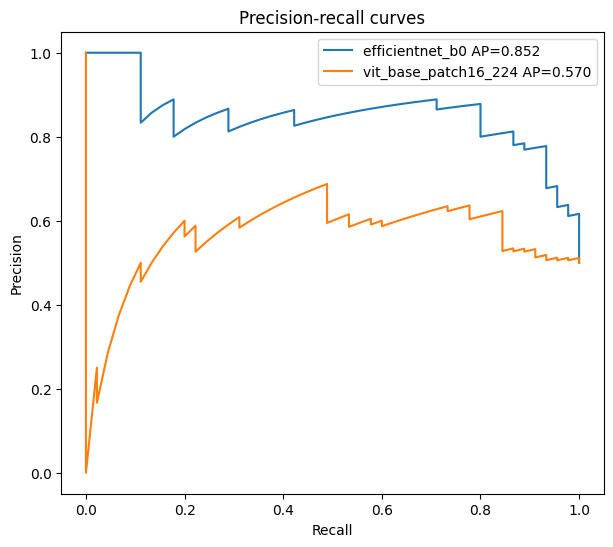

In [ ]:
iv=metrics_df.query("split=='internal_test' and level=='video'")
display(iv[["model","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","eer"]].round(4))

cols=["accuracy","f1","roc_auc","pr_auc"]; x=np.arange(len(iv)); w=.18
plt.figure(figsize=(11,5))
for i,c in enumerate(cols): plt.bar(x+(i-1.5)*w,iv[c],w,label=c)
plt.xticks(x,iv.model); plt.ylim(0,1.02); plt.title("Internal video-level comparison"); plt.legend(); plt.show()

for _,r in iv.iterrows():
    d=preds[(r.model,"internal_test","video")]; pr=(d.prob_fake>=r.threshold).astype(int)
    cm=confusion_matrix(d.label,pr,labels=[0,1])
    plt.figure(figsize=(5,4)); plt.imshow(cm); plt.title(f"{r.model} confusion matrix")
    plt.xticks([0,1],["Real","Fake"]); plt.yticks([0,1],["Real","Fake"])
    for i in range(2):
        for j in range(2): plt.text(j,i,cm[i,j],ha="center",va="center")
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.colorbar(); plt.show()

plt.figure(figsize=(7,6))
for _,r in iv.iterrows():
    d=preds[(r.model,"internal_test","video")]; fpr,tpr,_=roc_curve(d.label,d.prob_fake)
    plt.plot(fpr,tpr,label=f"{r.model} AUC={r.roc_auc:.3f}")
plt.plot([0,1],[0,1],"--"); plt.title("ROC curves"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

plt.figure(figsize=(7,6))
for _,r in iv.iterrows():
    d=preds[(r.model,"internal_test","video")]; p,rec,_=precision_recall_curve(d.label,d.prob_fake)
    plt.plot(rec,p,label=f"{r.model} AP={r.pr_auc:.3f}")
plt.title("Precision-recall curves"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()

## 13. Select best model using validation only

In [ ]:
vv=metrics_df.query("split=='validation' and level=='video'").sort_values(["roc_auc","f1"],ascending=False)
best=vv.iloc[0]
BEST_MODEL=best.model; BEST_THRESHOLD=float(best.threshold); BEST_CKPT=checkpoints[BEST_MODEL]
print("Selected:",BEST_MODEL,"Validation AUC:",best.roc_auc,"Threshold:",BEST_THRESHOLD)

Selected: efficientnet_b0 Validation AUC: 0.8893827160493828 Threshold: 0.6590217288273076


## 14. External testing dataset

External dataset manifest:


,video_path,video_id,label,class_name,source,split
0,/kaggle/input/datasets/chandashekar8/deepfake-...,model1,0,Real,External,external_test
1,/kaggle/input/datasets/chandashekar8/deepfake-...,modeloutput1,1,Fake,External,external_test



External class distribution:


,videos
class_name,
Real,1
Fake,1



External labels:
model1: Real (label=0)
modeloutput1: Fake (label=1)


...

,video_id,status,frames_saved,read_failures
0,model1,completed,16,0
1,modeloutput1,completed,16,0


External frames: 32
External videos represented: 2

External video predictions:


,video_id,label,prob_fake,prediction,confidence,frames
0,model1,0,0.0000,Real,1.0000,16
1,modeloutput1,1,0.0537,Real,0.9463,16



External video-level metrics:


,model,split,level,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,eer,threshold,tn,fp,fn,tp
0,efficientnet_b0,external_test,video,0.5,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.659,1,0,1,0


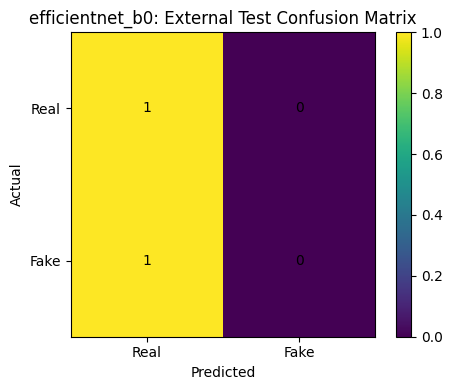


External classification report:
              precision    recall  f1-score   support

        Real       0.50      1.00      0.67         1
        Fake       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



In [ ]:
# ============================================================
# External dataset evaluation — corrected version
# ============================================================

def external_label(path):
    """
    Infer the external-test label from the filename only.

    Expected dataset convention:
    - model1.mp4       -> Real
    - modeloutput1.mp4 -> Fake

    Using the complete path would incorrectly classify every file
    as fake because the dataset directory contains 'deepfake'.
    """
    filename = Path(path).stem.lower()

    fake_tokens = [
        "modeloutput",
        "fake",
        "manipulated",
        "generated",
        "synthetic"
    ]

    real_tokens = [
        "real",
        "original",
        "authentic",
        "genuine"
    ]

    if any(token in filename for token in fake_tokens):
        return 1

    if any(token in filename for token in real_tokens):
        return 0

    # In this Kaggle dataset, model1.mp4 is the real video.
    if filename.startswith("model") and "output" not in filename:
        return 0

    return -1


# ------------------------------------------------------------
# Build external video manifest
# ------------------------------------------------------------

external_videos = videos_under(CFG.EXTERNAL_ROOT)

external_rows = []

for video_path in external_videos:
    label = external_label(video_path)

    external_rows.append({
        "video_path": str(video_path),
        "video_id": video_path.stem,
        "label": int(label),
        "class_name": (
            "Real"
            if label == 0
            else "Fake"
            if label == 1
            else "Unknown"
        ),
        "source": "External",
        "split": "external_test"
    })

ext = pd.DataFrame(external_rows)

if ext.empty:
    print(
        "External dataset was not found. Attach the "
        "'Deepfake Testing Videos' dataset to the Kaggle notebook."
    )

else:
    print("External dataset manifest:")
    display(ext)

    print("\nExternal class distribution:")
    display(
        ext["class_name"]
        .value_counts()
        .rename("videos")
        .to_frame()
    )

    ext.to_csv(
        CFG.OUT / "external_manifest_review.csv",
        index=False
    )

    # Confirm expected labels before continuing.
    print("\nExternal labels:")
    for row in ext.itertuples(index=False):
        print(
            f"{row.video_id}: "
            f"{row.class_name} "
            f"(label={row.label})"
        )

    # --------------------------------------------------------
    # Extract external frames using the optimized extractor
    # --------------------------------------------------------

    external_frame_records = []
    external_processing_log = []

    for row in tqdm(
        list(ext.itertuples(index=False)),
        desc="Extracting external test frames"
    ):
        result = extract_video_fast(row)

        external_frame_records.extend(
            result["records"]
        )

        external_processing_log.append({
            "video_id": result["video_id"],
            "status": result["status"],
            "frames_saved": len(result["records"]),
            "read_failures": result["read_failures"]
        })

    ext_frames = pd.DataFrame(
        external_frame_records
    )

    external_log_df = pd.DataFrame(
        external_processing_log
    )

    if ext_frames.empty:
        raise RuntimeError(
            "No frames were extracted from the external dataset."
        )

    ext_frames.to_csv(
        CFG.OUT / "external_frame_manifest.csv",
        index=False
    )

    external_log_df.to_csv(
        CFG.OUT / "external_frame_extraction_log.csv",
        index=False
    )

    print("\nExternal frame extraction summary:")
    display(external_log_df)

    print(
        "External frames:",
        len(ext_frames)
    )

    print(
        "External videos represented:",
        ext_frames["video_id"].nunique()
    )

    # --------------------------------------------------------
    # Create external DataLoader
    # --------------------------------------------------------

    external_dataset = FrameDS(
        ext_frames,
        eval_tf
    )

    ext_loader = DataLoader(
        external_dataset,
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Load selected model and generate predictions
    # --------------------------------------------------------

    selected_model, _ = load_ckpt(
        BEST_CKPT
    )

    ext_frame_predictions = predict(
        selected_model,
        ext_loader,
        use_tta=True
    )

    ext_video = video_level(
        ext_frame_predictions
    )

    ext_video["prediction_label"] = (
        ext_video["prob_fake"]
        >= BEST_THRESHOLD
    ).astype(int)

    ext_video["prediction"] = np.where(
        ext_video["prediction_label"] == 1,
        "Fake",
        "Real"
    )

    ext_video["confidence"] = np.where(
        ext_video["prediction_label"] == 1,
        ext_video["prob_fake"],
        1.0 - ext_video["prob_fake"]
    )

    ext_video.to_csv(
        CFG.OUT / "external_predictions.csv",
        index=False
    )

    print("\nExternal video predictions:")
    display(
        ext_video[
            [
                "video_id",
                "label",
                "prob_fake",
                "prediction",
                "confidence",
                "frames"
            ]
        ].round(4)
    )

    # --------------------------------------------------------
    # Calculate external metrics when both classes are present
    # --------------------------------------------------------

    labelled_external = ext_video[
        ext_video["label"] >= 0
    ].copy()

    if labelled_external["label"].nunique() == 2:

        external_metrics = calculate_metrics(
            labelled_external["label"],
            labelled_external["prob_fake"],
            BEST_THRESHOLD
        )

        external_metrics_df = pd.DataFrame(
            [{
                "model": BEST_MODEL,
                "split": "external_test",
                "level": "video",
                **external_metrics
            }]
        )

        external_metrics_df.to_csv(
            CFG.OUT / "external_metrics.csv",
            index=False
        )

        print("\nExternal video-level metrics:")
        display(
            external_metrics_df.round(4)
        )

        # Confusion matrix
        external_predictions = (
            labelled_external["prob_fake"]
            >= BEST_THRESHOLD
        ).astype(int)

        external_cm = confusion_matrix(
            labelled_external["label"],
            external_predictions,
            labels=[0, 1]
        )

        plt.figure(figsize=(5, 4))
        plt.imshow(external_cm)
        plt.title(
            f"{BEST_MODEL}: External Test Confusion Matrix"
        )
        plt.xticks(
            [0, 1],
            ["Real", "Fake"]
        )
        plt.yticks(
            [0, 1],
            ["Real", "Fake"]
        )
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        for i in range(2):
            for j in range(2):
                plt.text(
                    j,
                    i,
                    external_cm[i, j],
                    ha="center",
                    va="center"
                )

        plt.colorbar()
        plt.tight_layout()
        plt.show()

        print("\nExternal classification report:")
        print(
            classification_report(
                labelled_external["label"],
                external_predictions,
                labels=[0, 1],
                target_names=["Real", "Fake"],
                zero_division=0
            )
        )

    else:
        print(
            "Full external metrics require verified examples "
            "from both the Real and Fake classes."
        )

    del selected_model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 15. Error analysis

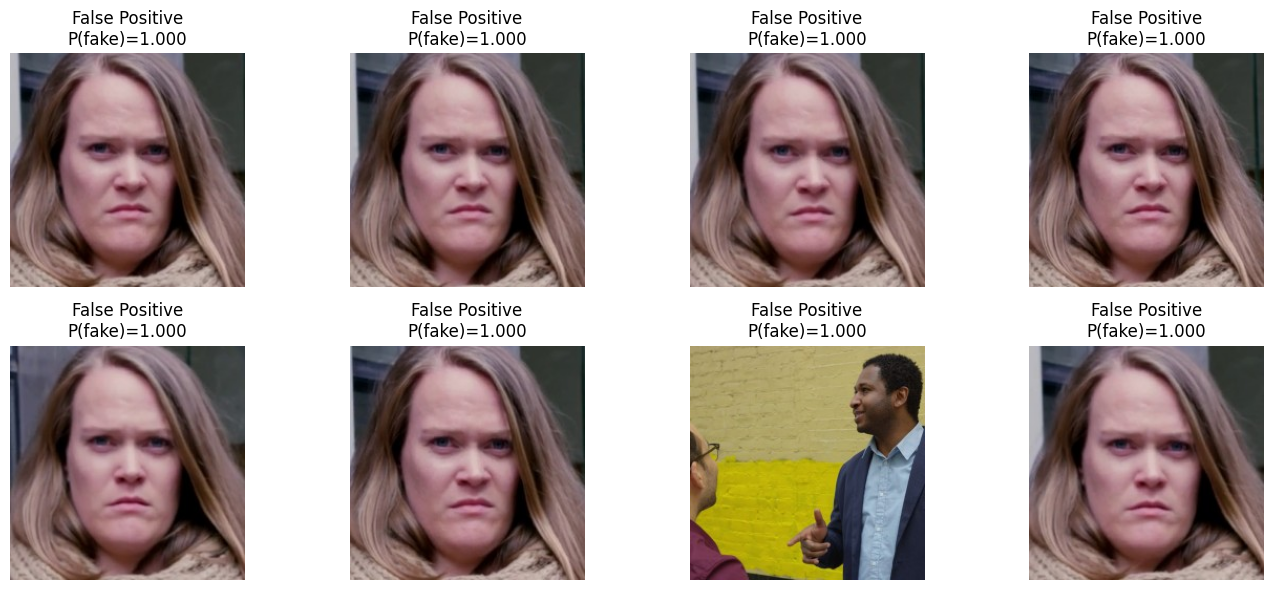

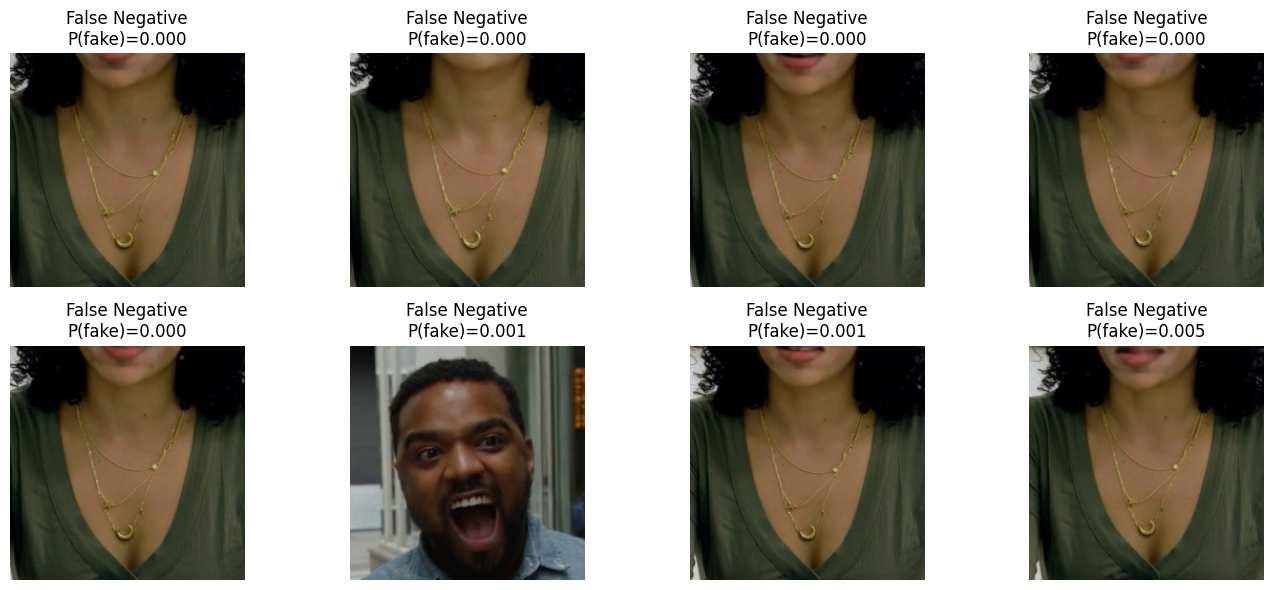

In [ ]:
d=preds[(BEST_MODEL,"internal_test","frame")].copy()
d["pred"]=(d.prob_fake>=BEST_THRESHOLD).astype(int)
d["error"]=np.where((d.label==0)&(d.pred==1),"False Positive",
             np.where((d.label==1)&(d.pred==0),"False Negative","Correct"))
for kind in ["False Positive","False Negative"]:
    s=d[d.error==kind].sort_values("prob_fake",ascending=(kind=="False Negative")).head(8)
    if s.empty: print("No",kind); continue
    plt.figure(figsize=(14,6))
    for i,r in enumerate(s.itertuples(index=False),1):
        plt.subplot(2,4,i); plt.imshow(Image.open(r.frame_path)); plt.title(f"{kind}\nP(fake)={r.prob_fake:.3f}"); plt.axis("off")
    plt.tight_layout(); plt.show()

## 16. Grad-CAM for EfficientNet-B0

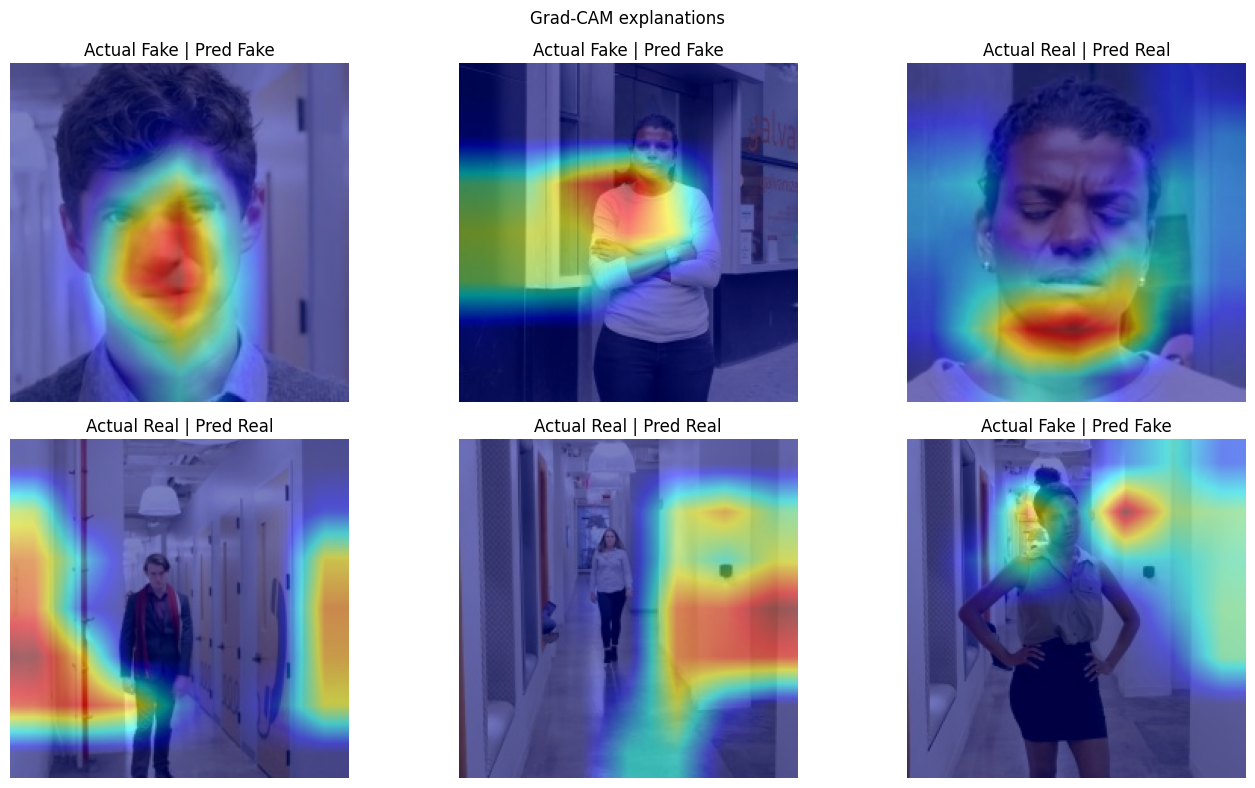

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

m,_=load_ckpt(checkpoints["efficientnet_b0"])
cam=GradCAM(model=m,target_layers=[m.conv_head])
s=te.sample(min(6,len(te)),random_state=CFG.SEED)
plt.figure(figsize=(14,8))
for i,r in enumerate(s.itertuples(index=False),1):
    pil=Image.open(r.frame_path).convert("RGB").resize((CFG.IMAGE_SIZE,CFG.IMAGE_SIZE))
    rgb=np.asarray(pil).astype(np.float32)/255
    x=eval_tf(pil).unsqueeze(0).to(CFG.DEVICE)
    with torch.no_grad(): pc=int(m(x).argmax(1))
    mask=cam(input_tensor=x,targets=[ClassifierOutputTarget(pc)])[0]
    overlay=show_cam_on_image(rgb,mask,use_rgb=True)
    plt.subplot(2,3,i); plt.imshow(overlay); plt.title(f"Actual {r.class_name} | Pred {'Fake' if pc else 'Real'}"); plt.axis("off")
plt.suptitle("Grad-CAM explanations"); plt.tight_layout(); plt.show()

## 17. Export final model for Flask

In [ ]:
c=torch.load(BEST_CKPT,map_location="cpu",weights_only=False)
export={"model_name":BEST_MODEL,"state_dict":c["state_dict"],"image_size":CFG.IMAGE_SIZE,
        "threshold":BEST_THRESHOLD,"frames_per_video":CFG.FRAMES_PER_VIDEO,
        "mean":MEAN,"std":STD,"class_names":["Real","Fake"]}
torch.save(export,CFG.EXPORT/"deepfake_model.pt")
with open(CFG.EXPORT/"model_config.json","w") as f:
    json.dump({k:v for k,v in export.items() if k!="state_dict"},f,indent=2)
print(CFG.EXPORT/"deepfake_model.pt")

/kaggle/working/deepfake_outputs/flask_export/deepfake_model.pt


## 18. Create local Flask application ZIP

In [ ]:
root=CFG.OUT/"deepfake_flask_app"; (root/"templates").mkdir(parents=True,exist_ok=True); (root/"static").mkdir(exist_ok=True)
shutil.copy2(CFG.EXPORT/"deepfake_model.pt",root/"deepfake_model.pt")

app_code=r"""
import tempfile
from pathlib import Path
import cv2, numpy as np, torch, timm
from PIL import Image
from flask import Flask,render_template,request
from torchvision import transforms

app=Flask(__name__); app.config["MAX_CONTENT_LENGTH"]=200*1024*1024
BASE=Path(__file__).parent; device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
ck=torch.load(BASE/"deepfake_model.pt",map_location=device)
model=timm.create_model(ck["model_name"],pretrained=False,num_classes=2,drop_rate=.25)
model.load_state_dict(ck["state_dict"]); model.to(device).eval()
tf=transforms.Compose([transforms.Resize((ck["image_size"],ck["image_size"])),transforms.ToTensor(),
                       transforms.Normalize(ck["mean"],ck["std"])])
fd=cv2.CascadeClassifier(cv2.data.haarcascades+"haarcascade_frontalface_default.xml")

def crop(frame):
    g=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY); faces=fd.detectMultiScale(g,1.1,5,minSize=(40,40))
    if len(faces):
        x,y,w,h=max(faces,key=lambda z:z[2]*z[3]); mx=int(.2*w); my=int(.2*h)
        return frame[max(0,y-my):min(frame.shape[0],y+h+my),max(0,x-mx):min(frame.shape[1],x+w+mx)]
    h,w=frame.shape[:2]; s=min(h,w); return frame[(h-s)//2:(h+s)//2,(w-s)//2:(w+s)//2]

@torch.no_grad()
def frame_prob(frame):
    rgb=cv2.cvtColor(crop(frame),cv2.COLOR_BGR2RGB)
    x=tf(Image.fromarray(rgb)).unsqueeze(0).to(device)
    return float(torch.softmax(model(x),1)[0,1])

def video_prob(path):
    cap=cv2.VideoCapture(str(path)); n=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    probs=[]
    for idx in np.linspace(0,max(n-1,0),ck["frames_per_video"]).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES,int(idx)); ok,f=cap.read()
        if ok: probs.append(frame_prob(f))
    cap.release()
    if not probs: raise ValueError("No readable frames found.")
    return float(np.mean(probs)),len(probs)

@app.route("/",methods=["GET","POST"])
def index():
    result=error=None
    if request.method=="POST":
        f=request.files.get("file")
        if not f or not f.filename: error="Select an image or video."
        else:
            suffix=Path(f.filename).suffix.lower(); tmp=None
            try:
                with tempfile.NamedTemporaryFile(delete=False,suffix=suffix) as t: f.save(t.name); tmp=Path(t.name)
                if suffix in {".jpg",".jpeg",".png"}:
                    frame=cv2.imread(str(tmp)); p=frame_prob(frame); details="Image analysed"
                else:
                    p,n=video_prob(tmp); details=f"{n} uniformly sampled frames analysed"
                label="FAKE" if p>=ck["threshold"] else "REAL"
                conf=p if label=="FAKE" else 1-p
                result={"label":label,"confidence":100*conf,"fake":100*p,"details":details}
            except Exception as e: error=str(e)
            finally:
                if tmp and tmp.exists(): tmp.unlink()
    return render_template("index.html",result=result,error=error)

if __name__=="__main__": app.run(debug=True,host="127.0.0.1",port=5000)
"""
html=r"""<!doctype html><html><head><meta charset="utf-8"><meta name="viewport" content="width=device-width">
<title>Deepfake Detector</title><link rel="stylesheet" href="{{url_for('static',filename='style.css')}}"></head>
<body><main><h1>Deepfake Detection</h1><p>Academic prototype. Uploads are deleted after inference.</p>
<section><form method="post" enctype="multipart/form-data"><input type="file" name="file" accept="image/*,video/*" required>
<button>Analyse</button></form>{% if error %}<div class="error">{{error}}</div>{% endif %}
{% if result %}<div class="result"><h2>{{result.label}}</h2><p>{{"%.2f"|format(result.confidence)}}% confidence</p>
<p>Fake probability: {{"%.2f"|format(result.fake)}}%</p><p>{{result.details}}</p></div>{% endif %}</section>
<p class="note">Research prototype only; not a forensic or legal verification service.</p></main></body></html>"""
css="""body{font-family:Arial;background:#eef3f8;color:#172033;margin:0}main{max-width:760px;margin:60px auto;padding:20px}
section{background:white;padding:28px;border-radius:18px;box-shadow:0 12px 40px #0002}h1{font-size:44px}
form{display:grid;gap:14px}input{padding:16px;border:1px dashed #789;border-radius:10px}
button{padding:14px;border:0;border-radius:10px;background:#1f67b1;color:white;font-weight:bold}
.result,.error{margin-top:20px;padding:18px;border-radius:12px}.result{background:#eef8f0}.error{background:#fff0ef}.note{color:#667}"""
req="""Flask==3.0.3
torch>=2.2
torchvision>=0.17
timm>=1.0.12
opencv-python>=4.9
Pillow>=10
numpy>=1.26"""
readme="""# Run locally
1. Extract the ZIP.
2. Create a virtual environment.
3. Run `pip install -r requirements.txt`.
4. Run `python app.py`.
5. Open http://127.0.0.1:5000
"""
(root/"app.py").write_text(app_code); (root/"templates"/"index.html").write_text(html)
(root/"static"/"style.css").write_text(css); (root/"requirements.txt").write_text(req); (root/"README.md").write_text(readme)
shutil.make_archive(str((CFG.OUT/"deepfake_flask_app").with_suffix("")),"zip",root)
print("Created",CFG.OUT/"deepfake_flask_app.zip")

Created /kaggle/working/deepfake_outputs/deepfake_flask_app.zip


## 19. Outputs

All artefacts are saved under `/kaggle/working/deepfake_outputs`, including:

- video and frame manifests
- all metrics
- model checkpoints
- external-test predictions
- selected model export
- `deepfake_flask_app.zip`

In [ ]:
import os
import shutil

source_folder = "/kaggle/working/deepfake_outputs"
zip_base_path = "/kaggle/working/deepfake_outputs"

if not os.path.isdir(source_folder):
    raise FileNotFoundError(f"Folder not found: {source_folder}")

zip_file = shutil.make_archive(
    base_name=zip_base_path,
    format="zip",
    root_dir="/kaggle/working",
    base_dir="deepfake_outputs"
)

size_mb = os.path.getsize(zip_file) / (1024 ** 2)

print("ZIP created successfully")
print(f"Location: {zip_file}")
print(f"Size: {size_mb:.2f} MB")

ZIP created successfully
Location: /kaggle/working/deepfake_outputs.zip
Size: 468.00 MB
